# IntellBank Data Exploration & Cleaning

### Pipeline Flow Confirmation:
1. **OCR & Extraction:** PDF is uploaded and converted to raw text.
2. **Data Cleaning (This Step):** We analyze the raw text, remove missing values, filter outliers (e.g. extremely short/long strings), and standardize the text.
3. **Data Transformation (Separated):**
   - *For Generation (FLAN-T5):* Transform clean data into `input_text` and `target_text` pairs.
   - *For Topic Heatmap:* Transform clean data into TF-IDF vectors for clustering.

In [1]:
!pip install matplotlib seaborn jupyter numpy pandas scikit-learn wordcloud scipy

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.6.1-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jupyter_builder-1.1.0-py3-none-any.whl.metadata (7.7 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.20.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached ter

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")
DATASET_PATH = os.path.join("app", "data", "training_dataset.csv")

# Load the data
df = pd.read_csv(DATASET_PATH)
df['target_len'] = df['target_text'].astype(str).str.len()
df['input_len'] = df['input_text'].astype(str).str.len()


In [3]:
# list out the table of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject      86 non-null     str    
 1   topic        86 non-null     str    
 2   difficulty   86 non-null     str    
 3   marks        61 non-null     float64
 4   year         86 non-null     int64  
 5   input_text   86 non-null     str    
 6   target_text  86 non-null     str    
 7   source_file  86 non-null     str    
 8   pyp_id       86 non-null     str    
 9   target_len   86 non-null     int64  
 10  input_len    86 non-null     int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 7.5 KB


In [4]:
df.head()

,subject,topic,difficulty,marks,year,input_text,target_text,source_file,pyp_id,target_len,input_len
0,Software Project Management,Stakeholders,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and describe TWO (2) stakeholders of ...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,62,81
1,Software Project Management,Software Process Model,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and explain TWO (2) types of prototyp...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,145,91
2,Software Project Management,Software Process Model,Medium,NaN,2026,Generate a Medium Software Project Management...,A network diagram can be used to illustrate th...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,491,85
3,Software Project Management,Network Diagram,Hard,8.0,2026,Generate a Hard 8-mark Software Project Manage...,"Create a network diagram based on the task ID,...",Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,94,82
4,Software Project Management,Network Diagram,Medium,5.0,2026,Generate a Medium 5-mark Software Project Mana...,Based on the answer given in Question 1 c) (i)...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,206,84


In [5]:
df.isnull().sum()

subject         0
topic           0
difficulty      0
marks          25
year            0
input_text      0
target_text     0
source_file     0
pyp_id          0
target_len      0
input_len       0
dtype: int64

## Step 1: Show Raw Values and Missing Data
Before we generate any graphs or do any cleaning, let's look at the raw state of our dataset.

In [6]:
print("--- DATASET INFO ---")
df.info()

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- STATISTICAL SUMMARY (Character Lengths) ---")
display(df[['input_len', 'target_len']].describe())

print("\n--- FIRST 5 ROWS ---")
display(df.head())

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject      86 non-null     str    
 1   topic        86 non-null     str    
 2   difficulty   86 non-null     str    
 3   marks        61 non-null     float64
 4   year         86 non-null     int64  
 5   input_text   86 non-null     str    
 6   target_text  86 non-null     str    
 7   source_file  86 non-null     str    
 8   pyp_id       86 non-null     str    
 9   target_len   86 non-null     int64  
 10  input_len    86 non-null     int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 7.5 KB

--- MISSING VALUES ---
subject         0
topic           0
difficulty      0
marks          25
year            0
input_text      0
target_text     0
source_file     0
pyp_id          0
target_len      0
input_len       0
dtype: int64

--- STATISTICAL SUMMARY (Character Lengths) ---

,input_len,target_len
count,86.000000,86.000000
mean,77.418605,315.500000
std,7.041833,251.956894
min,67.000000,48.000000
25%,71.000000,162.000000
50%,78.000000,239.000000
75%,83.000000,437.500000
max,95.000000,1372.000000



--- FIRST 5 ROWS ---


,subject,topic,difficulty,marks,year,input_text,target_text,source_file,pyp_id,target_len,input_len
0,Software Project Management,Stakeholders,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and describe TWO (2) stakeholders of ...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,62,81
1,Software Project Management,Software Process Model,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and explain TWO (2) types of prototyp...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,145,91
2,Software Project Management,Software Process Model,Medium,NaN,2026,Generate a Medium Software Project Management...,A network diagram can be used to illustrate th...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,491,85
3,Software Project Management,Network Diagram,Hard,8.0,2026,Generate a Hard 8-mark Software Project Manage...,"Create a network diagram based on the task ID,...",Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,94,82
4,Software Project Management,Network Diagram,Medium,5.0,2026,Generate a Medium 5-mark Software Project Mana...,Based on the answer given in Question 1 c) (i)...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,206,84


In [7]:
categorical_data = df.select_dtypes(include=['object'])
continuous_data = df.select_dtypes(include=['int64', 'float64'])

print("Categorical Data")
i = 1
for cate_columns in categorical_data.columns:
    print(f"{i}. {cate_columns}")
    i+=1

print("\nContinuous Data")
i = 1
for cont_columns in continuous_data.columns:
    print(f"{i}. {cont_columns}")
    i+=1

Categorical Data
1. subject
2. topic
3. difficulty
4. input_text
5. target_text
6. source_file
7. pyp_id

Continuous Data
1. marks
2. year
3. target_len
4. input_len


C:\Users\samch\AppData\Local\Temp\ipykernel_17540\3363940434.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data = df.select_dtypes(include=['object'])


## Step 2: Data Cleaning Suggestions & Choices

Based on the raw data above, here are the standard choices you have for cleaning this OCR data before passing it to transformation:

1. **Drop Missing Values (NaNs):** Remove any row where `target_text` or `input_text` is entirely blank or null.
2. **Outlier Removal (Length):** 
   - Drop rows where `target_len < 10` (likely an OCR error that just captured a single word).
   - Drop rows where `target_len > 1500` (likely an OCR error that merged 5 questions into 1).
3. **Text Standardization:** Convert all text to lowercase, remove weird characters (e.g., `\r\n`), and strip extra whitespaces. (Already mostly done in `ocr_to_dataset.py`, but good to double-check).
4. **Drop Unknown Topics:** If a topic was classified as 'Unknown', do you want to keep it or drop it?

### Let's visualize the data to see if we need outlier removal:

In [8]:
df_clean = df.dropna(subset=['input_text', 'target_text', 'topic'])

df_clean = df_clean[df_clean['topic'] != 'Unknown']

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
print(f"Total rows removed: {len(df) - len(df_clean)}")

df = df_clean


Original row count: 86
Cleaned row count: 79
Total rows removed: 7


C:\Users\samch\AppData\Local\Temp\ipykernel_17540\3437715888.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='difficulty', ax=axes[1], palette='viridis')


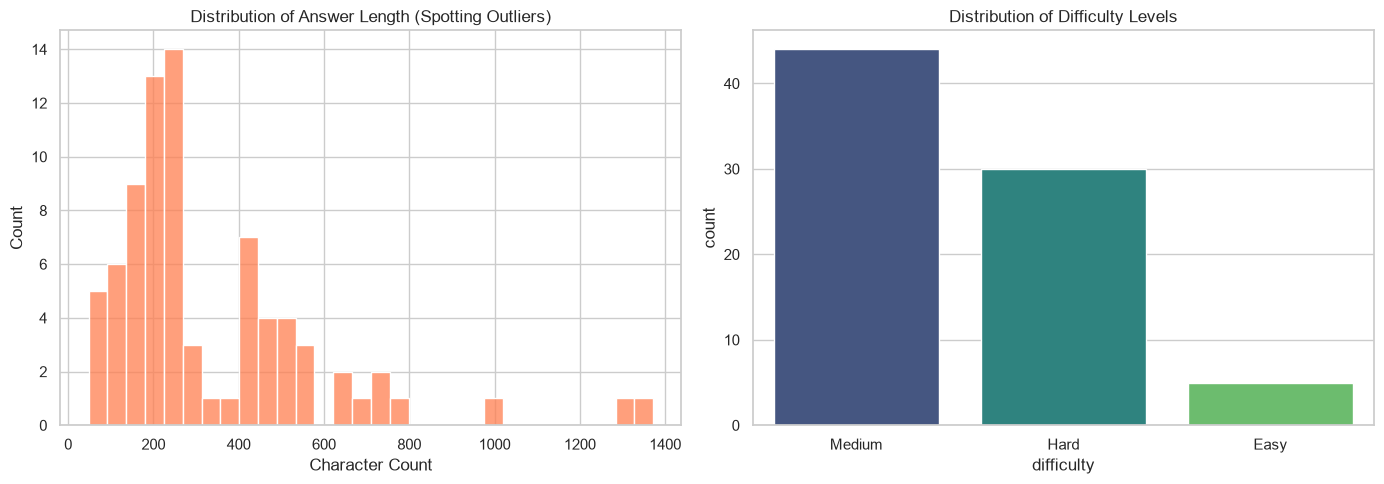

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length Distribution
sns.histplot(data=df, x='target_len', bins=30, ax=axes[0], color='coral')
axes[0].set_title('Distribution of Answer Length (Spotting Outliers)')
axes[0].set_xlabel('Character Count')

# Difficulty Distribution
sns.countplot(data=df, x='difficulty', ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Difficulty Levels')

plt.tight_layout()
plt.show()

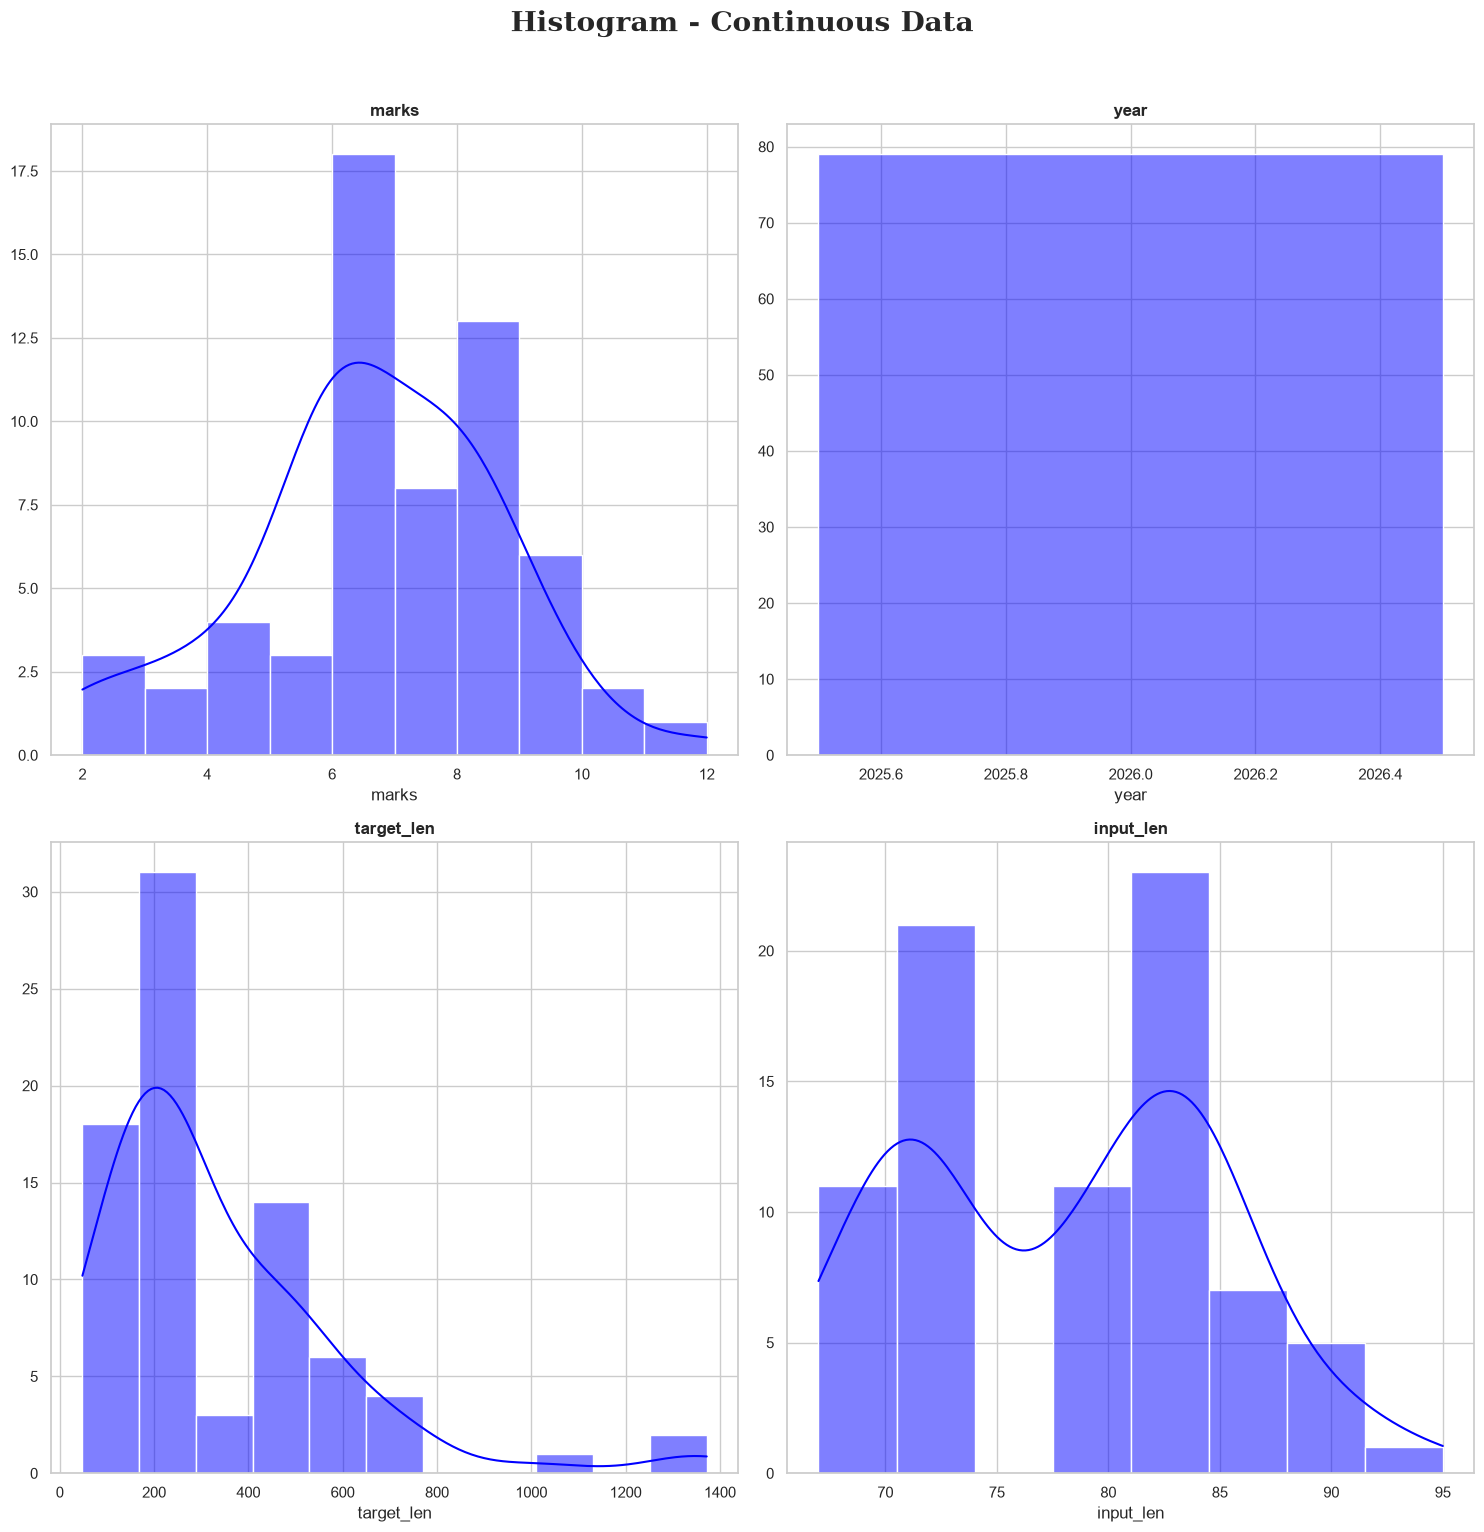

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs = axs.flatten()

for i, column in enumerate(continuous_data.columns):
    sns.histplot(data=df, x=column, ax=axs[i], kde=True, color='blue')
    axs[i].set_title(column, fontweight='bold')
    axs[i].set_ylabel('')

    fig.suptitle(
        "Histogram - Continuous Data",
        fontsize = 20,
        fontweight = 'bold',
        fontfamily = 'serif',
        y=1.02
    )

plt.tight_layout()
plt.show()

In [11]:
# Drop the 'year' column permanently
df = df.drop(columns=['year'])


## Step 3: Data Transformation (Example: Clustering)
Once the data is cleaned above, we transform it. Here is the separated transformation path for your **Topic Heatmap**.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Clean the subset (drop missing)
clean_texts = df['target_text'].dropna().astype(str)

# 2. Transform into vectors
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X = vectorizer.fit_transform(clean_texts)

# 3. Run clustering algorithm
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(5):
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

Cluster 0: 000, table, project, task, code, duration, lines
Cluster 1: team, project, cvc, impact, dvc, probability, risk
Cluster 2: risk, cps, project, identify, variance, value, new
Cluster 3: risk, highest, calculation, exposure, suitable, cost, calculate
Cluster 4: software, quality, process, project, metrics, goal, given


---
# Part B &mdash; Dataset Distributions (Question Generator)

The charts below profile `training_dataset.csv`, the corpus behind the fine-tuned FLAN&#8209;T5 question
generator. They summarise how the 86 question&ndash;answer pairs are spread across topics, difficulty,
marks and answer length.

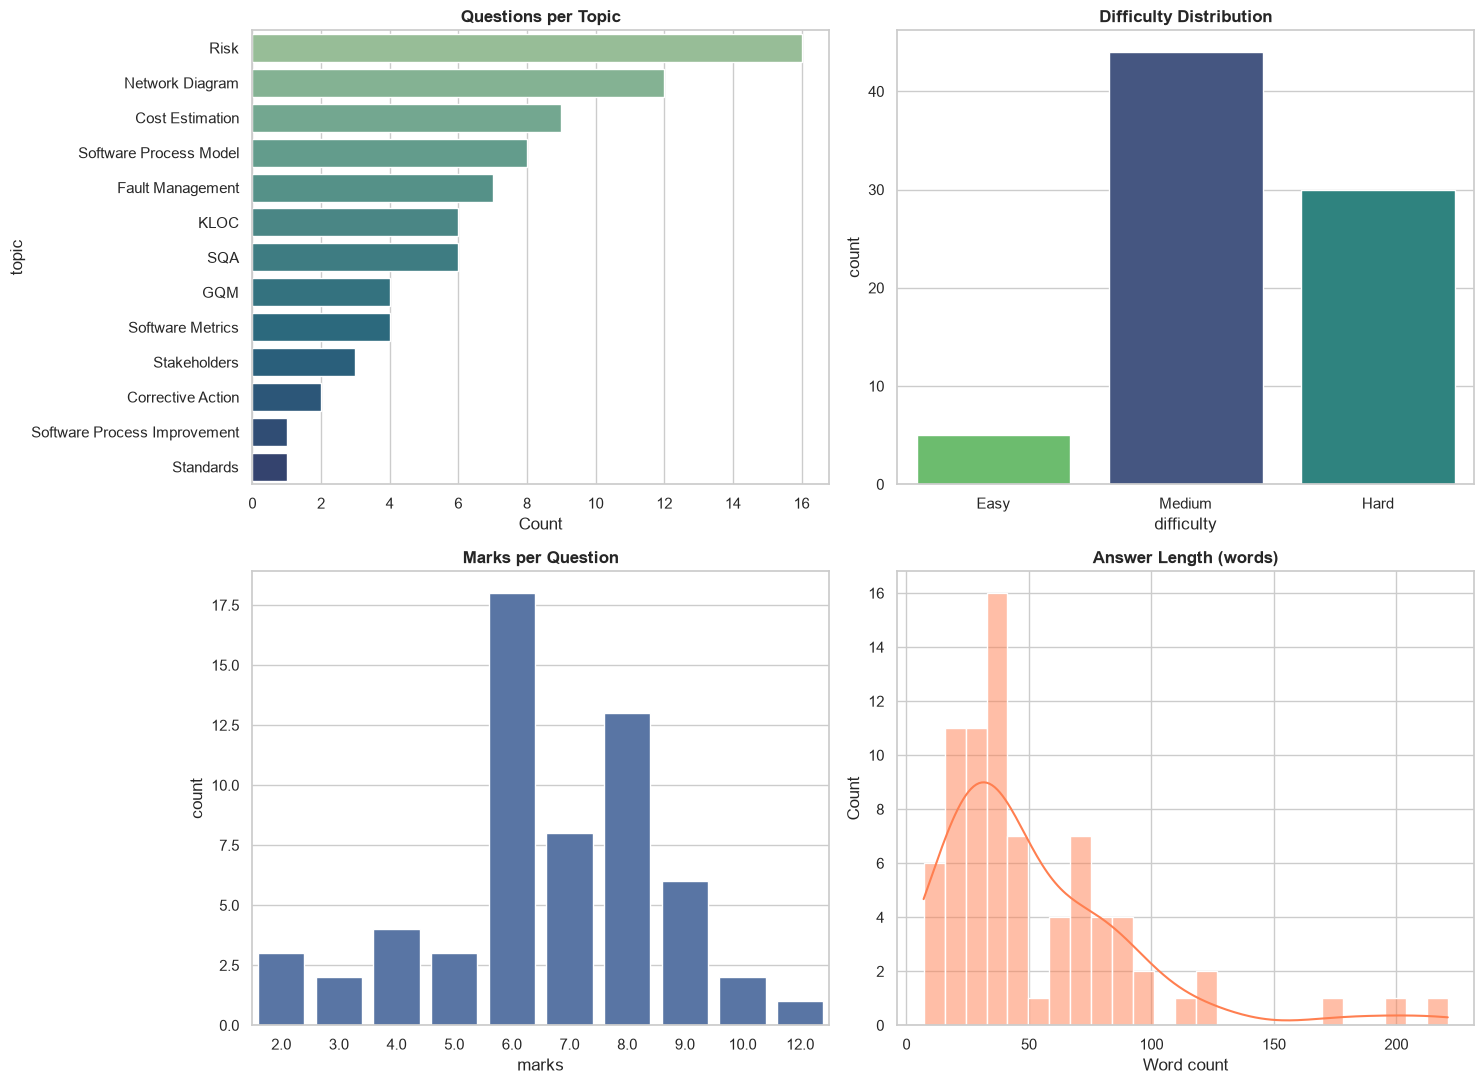

In [13]:
# Derived length columns (safe to re-run)
df['target_len']   = df['target_text'].astype(str).str.len()
df['input_len']    = df['input_text'].astype(str).str.len()
df['target_words'] = df['target_text'].astype(str).str.split().str.len()

fig, ax = plt.subplots(2, 2, figsize=(15, 11))

tc = df['topic'].value_counts()
sns.barplot(x=tc.values, y=tc.index, ax=ax[0, 0], hue=tc.index, palette='crest', legend=False)
ax[0, 0].set_title('Questions per Topic', fontweight='bold'); ax[0, 0].set_xlabel('Count')

sns.countplot(data=df, x='difficulty', order=['Easy', 'Medium', 'Hard'], ax=ax[0, 1],
              hue='difficulty', palette='viridis', legend=False)
ax[0, 1].set_title('Difficulty Distribution', fontweight='bold')

sns.countplot(data=df, x='marks', ax=ax[1, 0], color='#4C72B0')
ax[1, 0].set_title('Marks per Question', fontweight='bold')

sns.histplot(df['target_words'], bins=25, ax=ax[1, 1], color='coral', kde=True)
ax[1, 1].set_title('Answer Length (words)', fontweight='bold'); ax[1, 1].set_xlabel('Word count')

plt.tight_layout(); plt.show()

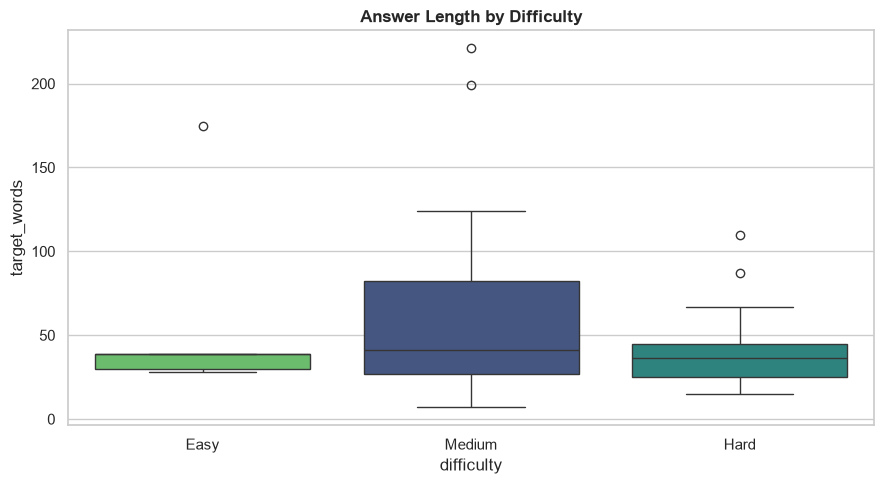

In [14]:
# Does a harder question demand a longer answer? Length spread per difficulty band.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='difficulty', y='target_words', order=['Easy', 'Medium', 'Hard'],
            hue='difficulty', palette='viridis', legend=False, ax=ax)
ax.set_title('Answer Length by Difficulty', fontweight='bold')
plt.tight_layout(); plt.show()

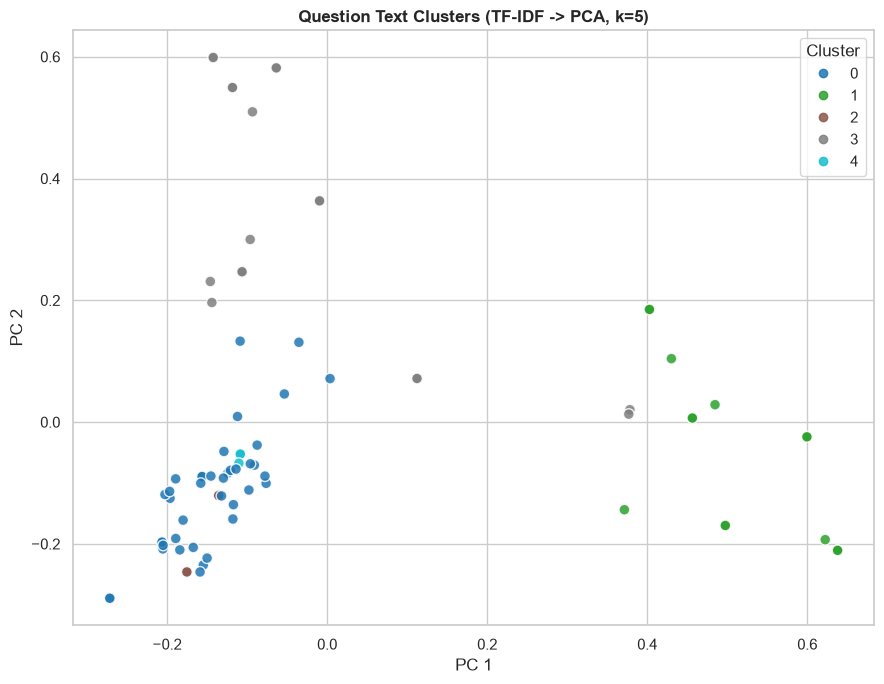

In [15]:
# Do the questions fall into natural themes? Vectorise the text, cluster it, and
# project to 2D so the clusters can be seen rather than just listed.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

texts  = df['target_text'].dropna().astype(str)
X      = TfidfVectorizer(stop_words='english', max_features=500).fit_transform(texts)
labels = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)
coords = PCA(n_components=2, random_state=42).fit_transform(X.toarray())

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=60, alpha=0.85, edgecolor='white')
ax.set_title('Question Text Clusters (TF-IDF -> PCA, k=5)', fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(*sc.legend_elements(), title='Cluster', loc='best')
plt.tight_layout(); plt.show()

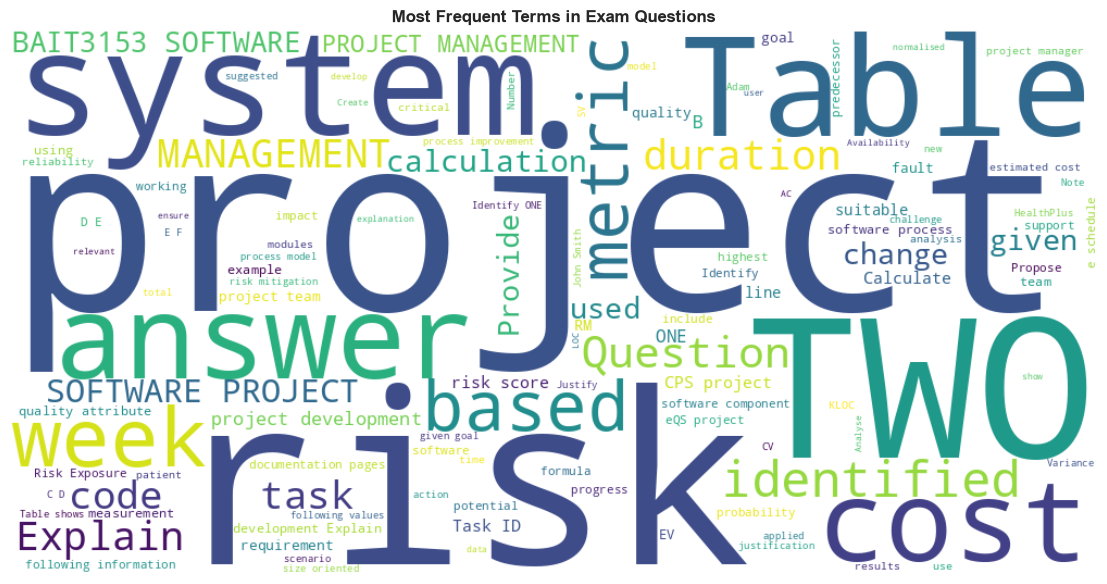

In [16]:
# The vocabulary at a glance. (If the import fails:  !pip install wordcloud)
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=500, background_color='white',
               colormap='viridis', max_words=120).generate(' '.join(texts))
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Most Frequent Terms in Exam Questions', fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part C &mdash; Class Weakness Model: Input Data (live database)

The generator above is only a fallback. The project's own AI is the **Class Weakness model**, an
unsupervised clustering algorithm. Its input is not a CSV but the live `student_performance` table in
Supabase &mdash; every row is one student's mastery band for one topic. The cells below pull that data
and profile it exactly as the model consumes it.

In [17]:
import os, warnings
warnings.filterwarnings('ignore')   # keep screenshot output clean

# Reuse the AI service's own DB helper (it already knows where the root .env is).
# Fall back to a direct connection if the notebook was launched from elsewhere.
try:
    from app.services.db_service import get_db_connection
    conn = get_db_connection()
except Exception:
    import psycopg2
    from dotenv import load_dotenv
    for _p in ['.env', '../.env', '../../.env']:
        if os.path.exists(_p):
            load_dotenv(_p); break
    conn = psycopg2.connect(
        host=os.getenv('SUPABASE_DB_HOST'), port=os.getenv('SUPABASE_DB_PORT', '5432'),
        dbname=os.getenv('SUPABASE_DB_NAME', 'postgres'), user=os.getenv('SUPABASE_DB_USER'),
        password=os.getenv('SUPABASE_DB_PASSWORD'), sslmode='require')

SUBJECT = 'Software Project Management'   # change to any subject with graded data
_q = '''
    SELECT u.email AS student, t.name AS topic, sp.mastery_level
    FROM student_performance sp
    JOIN topics   t  ON t.topic_id    = sp.topic_id
    JOIN subjects s  ON s.subject_id  = t.subject_id
    JOIN students st ON st.student_id = sp.student_id
    JOIN users    u  ON u.user_id     = st.user_id
    WHERE s.name = %s
'''
perf = pd.read_sql(_q, conn, params=(SUBJECT,))
conn.close()

# The band -> score mapping the model uses (see weakness_service.py)
BAND_SCORE = {'Beginner': 40, 'Intermediate': 60, 'Advanced': 80, 'Mastered': 95}
WEAK_BELOW = 50
perf['score'] = perf['mastery_level'].map(BAND_SCORE)

print(f"{len(perf)} records  |  {perf['student'].nunique()} students  |  {perf['topic'].nunique()} topics")

62 records  |  5 students  |  16 topics


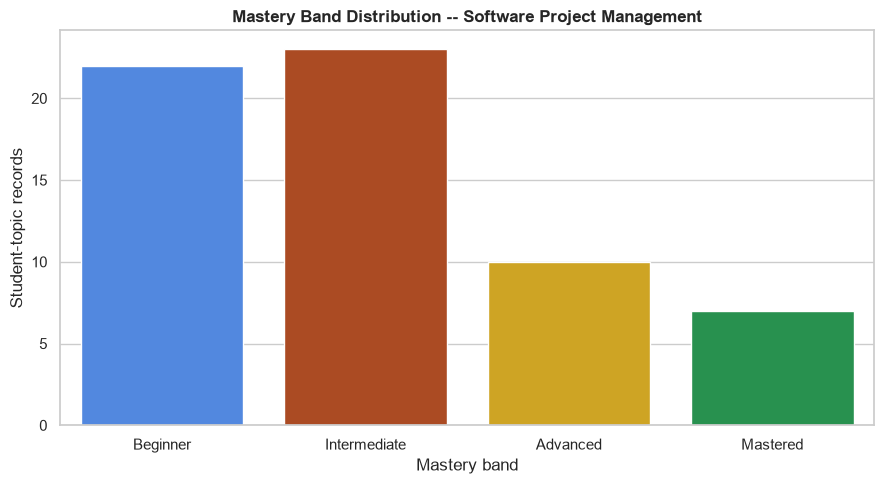

In [18]:
# How is the cohort spread across the four mastery bands?
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=perf, x='mastery_level',
              order=['Beginner', 'Intermediate', 'Advanced', 'Mastered'],
              hue='mastery_level',
              palette=['#C2410C', '#EAB308', '#3B82F6', '#16A34A'], legend=False, ax=ax)
ax.set_title(f'Mastery Band Distribution -- {SUBJECT}', fontweight='bold')
ax.set_xlabel('Mastery band'); ax.set_ylabel('Student-topic records')
plt.tight_layout(); plt.show()

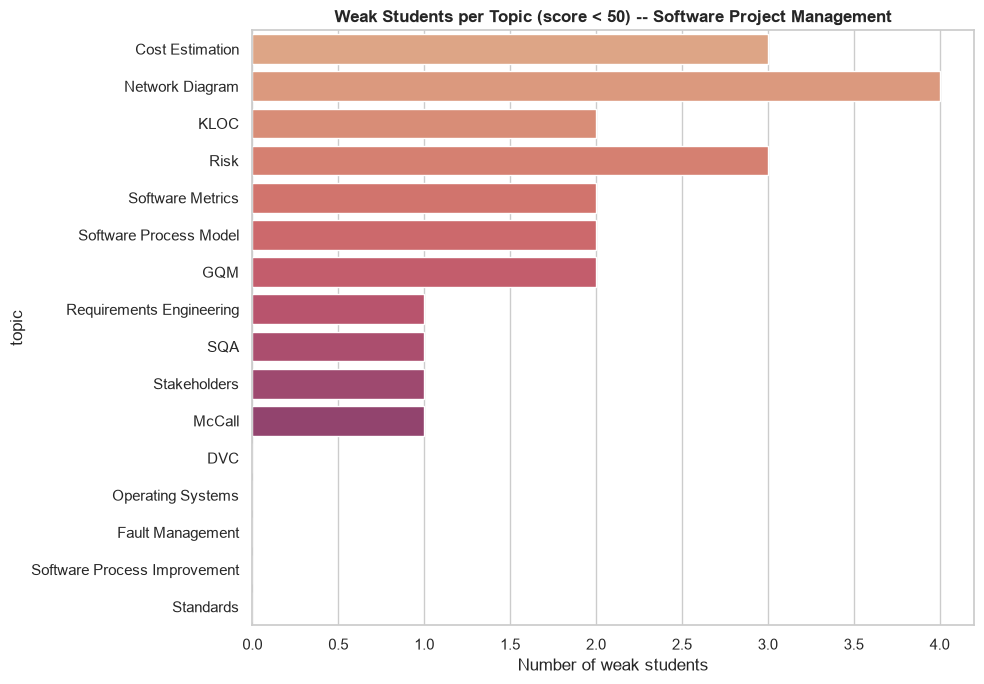

In [19]:
# Aggregate to the per-topic features the model actually clusters on.
g = perf.groupby('topic')['score']
feat = pd.DataFrame({
    'students_assessed': g.size(),
    'weak_students':     perf.assign(weak=perf['score'] < WEAK_BELOW).groupby('topic')['weak'].sum(),
    'mean_band':         g.mean(),
})
feat['pct_below_50'] = (100 * feat['weak_students'] / feat['students_assessed']).round()
feat = feat.sort_values('pct_below_50', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=feat['weak_students'], y=feat.index, hue=feat.index, palette='flare', legend=False, ax=ax)
ax.set_title(f'Weak Students per Topic (score < {WEAK_BELOW}) -- {SUBJECT}', fontweight='bold')
ax.set_xlabel('Number of weak students')
plt.tight_layout(); plt.show()

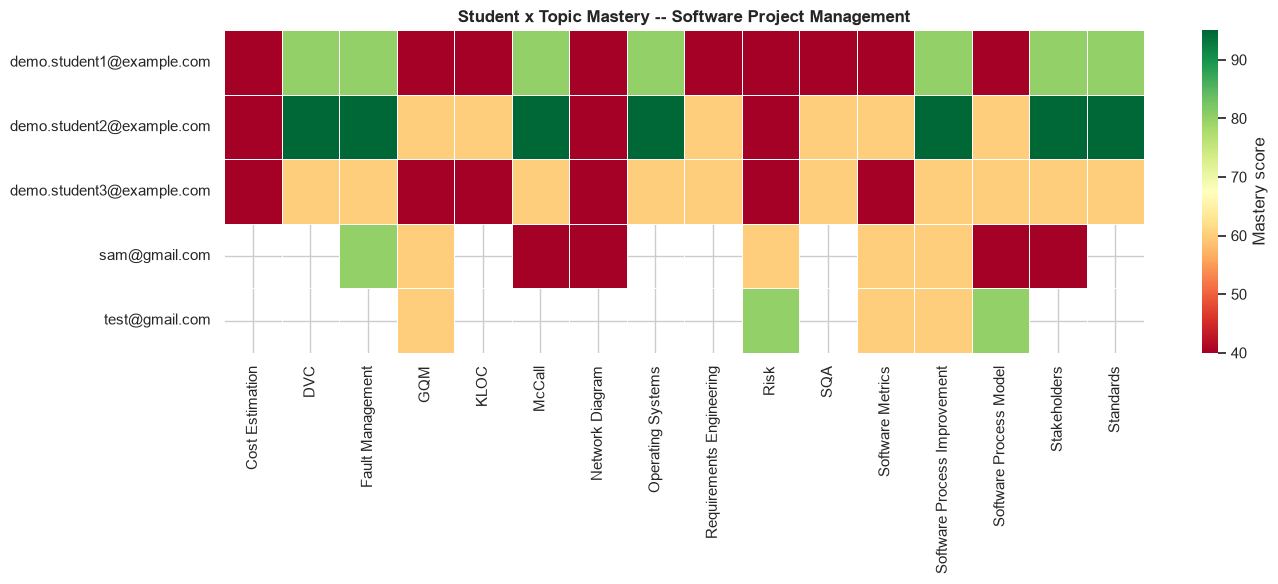

In [20]:
# The raw picture the model summarises: every student against every topic.
mat = perf.pivot_table(index='student', columns='topic', values='score', aggfunc='mean')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(mat, cmap='RdYlGn', vmin=40, vmax=95, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mastery score'}, ax=ax)
ax.set_title(f'Student x Topic Mastery -- {SUBJECT}', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

---
# Part D &mdash; Visualising the Agglomerative Clustering

The model turns each topic into a three-feature vector, standardises it, and repeatedly merges the two
closest topics until three weakness tiers remain. The scatter shows where topics sit in that feature
space; the dendrogram shows the exact order they were merged in &mdash; a direct picture of the algorithm
from Section 5.1.3. These cells use scikit&#8209;learn and SciPy to *visualise* the same technique the
service implements from first principles.

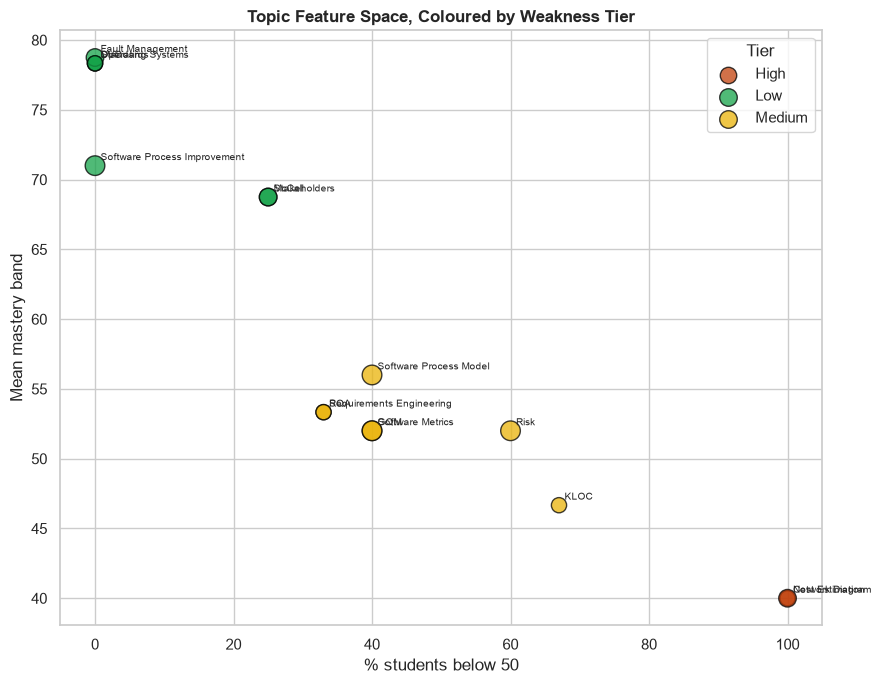

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Build and standardise the 3-D feature vector (matches weakness_service.py)
F = feat[['pct_below_50', 'mean_band', 'weak_students']].copy()
F['inv_band'] = 100 - F['mean_band']
Z = StandardScaler().fit_transform(F[['pct_below_50', 'inv_band', 'weak_students']])

labels = AgglomerativeClustering(n_clusters=min(3, len(F)), linkage='average').fit_predict(Z)
# Order the three clusters by average weakness -> High / Medium / Low
_order = feat.assign(cl=labels).groupby('cl')['pct_below_50'].mean().sort_values(ascending=False).index
_tier  = {c: ['High', 'Medium', 'Low'][min(i, 2)] for i, c in enumerate(_order)}
feat['tier'] = [_tier[c] for c in labels]

fig, ax = plt.subplots(figsize=(9, 7))
colours = {'High': '#C2410C', 'Medium': '#EAB308', 'Low': '#16A34A'}
for tier, sub in feat.groupby('tier'):
    ax.scatter(sub['pct_below_50'], sub['mean_band'], s=sub['students_assessed'] * 40,
               c=colours[tier], label=tier, alpha=0.75, edgecolor='black')
for name, r in feat.iterrows():
    ax.annotate(name, (r['pct_below_50'], r['mean_band']), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('% students below 50'); ax.set_ylabel('Mean mastery band')
ax.set_title('Topic Feature Space, Coloured by Weakness Tier', fontweight='bold')
ax.legend(title='Tier')
plt.tight_layout(); plt.show()

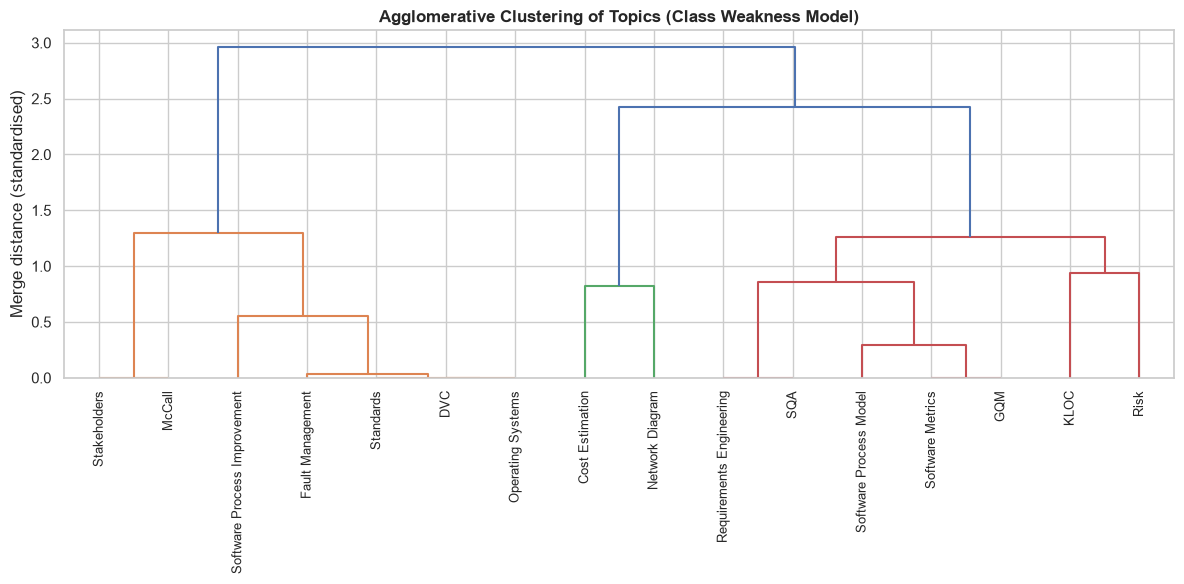

In [22]:
# The merge history itself: cut the tree where three colours remain to get the tiers.
from scipy.cluster.hierarchy import linkage, dendrogram

L = linkage(Z, method='average', metric='euclidean')
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(L, labels=list(feat.index), leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7 * max(L[:, 2]), ax=ax)
ax.set_title('Agglomerative Clustering of Topics (Class Weakness Model)', fontweight='bold')
ax.set_ylabel('Merge distance (standardised)')
plt.tight_layout(); plt.show()